# Model 

In [141]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [142]:
API_key = os.getenv("GOOGLE_API_KEY")
llm_model = "gemini-2.5-flash"

In [143]:
os.environ["LANGCHAIN_PROJECT"] = "RAG-Chatbot"

In [144]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [145]:
model = ChatGoogleGenerativeAI(
                    model=llm_model,
                    temperature=0,
                    timeout=None,
                    max_retries=2)

In [146]:
response = model.invoke("hello")

In [46]:
response.content

'Hello! How can I help you today?'

# document loading 

In [47]:
 from langchain_community.document_loaders import PyPDFLoader,TextLoader

In [48]:
DATA_PATH = "Data"

documents = []

for file_name in os.listdir(DATA_PATH):

    file_path = os.path.join(DATA_PATH, file_name)

    # PDF
    if file_name.endswith(".pdf"):
        loader = PyPDFLoader(file_path)
        documents.extend(loader.load())

    # TXT
    elif file_name.endswith(".txt"):
        loader = TextLoader(file_path, encoding="utf-8")
        documents.extend(loader.load())

print(f"Loaded {len(documents)} documents")

Loaded 1 documents


In [51]:
from pprint import pprint
doc = documents[0]

pprint(doc.metadata)

{'source': 'Data\\test.txt'}


In [53]:
print(doc.page_content)

Information security, cybersecurity and privacy 
protection — Information security management systems 
— Requirements
1  Scope
This document specifies the requirements for establishing, implementing, maintaining and continually 
improving an information security management system within the context of the organization. This 
document also includes requirements for the assessment and treatment of information security risks 
tailored to the needs of the organization. The requirements set out in this document are generic and are 
intended to be applicable to all organizations, regardless of type, size or nature. Excluding any of the 
requirements specified in Clauses 4 to 10 is not acceptable when an organization claims conformity to 
this document.
2  Normative references
The following documents are referred to in the text in such a way that some or all of their content 
constitutes requirements of this document. For dated references, only the edition cited applies. For 
undated referenc

# Chunking 

In [54]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [55]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150
)
doc_splits = text_splitter.split_documents(documents)

In [56]:
for chunck in doc_splits[:2]:
    print(chunck.page_content)
    print('='*100)

Information security, cybersecurity and privacy 
protection — Information security management systems 
— Requirements
1  Scope
This document specifies the requirements for establishing, implementing, maintaining and continually 
improving an information security management system within the context of the organization. This 
document also includes requirements for the assessment and treatment of information security risks 
tailored to the needs of the organization. The requirements set out in this document are generic and are 
intended to be applicable to all organizations, regardless of type, size or nature. Excluding any of the 
requirements specified in Clauses 4 to 10 is not acceptable when an organization claims conformity to 
this document.
2  Normative references
requirements specified in Clauses 4 to 10 is not acceptable when an organization claims conformity to 
this document.
2  Normative references
The following documents are referred to in the text in such a way that some o

 # Embedding and Store 

In [57]:
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

vectorstore = InMemoryVectorStore.from_documents(
    documents=doc_splits, embedding=embeddings
)
retriever = vectorstore.as_retriever()

# Create a retriever tool

In [69]:
from langchain.tools import tool

D:\LLMS\RAG-Chatbot\.venv\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [76]:
from langchain.tools import tool


@tool
def retrieve_documents(query: str) -> str:
    """
    Retrieve relevant information from uploaded documents.

    Use this tool ONLY when the question requires document context.
    """

    results = vectorstore.similarity_search_with_score(
        query,
        k=10
    )

    filtered_docs = []

    for doc, score in results:

        # InMemoryVectorStore:
        # larger score = better

        if score > 0.5:
            filtered_docs.append((doc, score))

    if not filtered_docs:
        return "No relevant information found in the uploaded documents."

    top_docs = filtered_docs[:3]

    output = []

    for i, (doc, score) in enumerate(top_docs):

        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page", "N/A")

        output.append(
            f"""
                Document {i + 1}
                                
                Source: {source}
                Page: {page}
                
                Content:
                {doc.page_content}
                """
        )

    return "\n\n".join(output)

In [86]:
pprint(retrieve_documents.invoke({"query":"what is Planning in iso"}))

('\n'
 '                Document 1\n'
 '\n'
 '                Similarity Score: 0.7221\n'
 '\n'
 '                Source: Data\\test.txt\n'
 '                Page: N/A\n'
 '\n'
 '                Content:\n'
 '                information security management system within the '
 'organization.\n'
 '6  Planning\n'
 '6.1  Actions to address risks and opportunities\n'
 '6.1.1  General\n'
 'When planning for the information security management system, the '
 'organization shall consider \n'
 'the issues referred to in 4.1 and the requirements referred to in 4.2 and '
 'determine the risks and \n'
 'opportunities that need to be addressed to:\n'
 'a) ensure the information security management system can achieve its '
 'intended outcome(s);\n'
 'b) prevent, or reduce, undesired effects; \n'
 'c) achieve continual improvement.\n'
 'The organization shall plan:\n'
 'd) actions to address these risks and opportunities; and\n'
 'e) how to\n'
 '1) integrate and implement the actions into its inform

# Start an Agentic RAG 

In [79]:
from langgraph.graph import MessagesState

In [82]:
def generate_query_or_respond(state: MessagesState):
    """Call the model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply respond to the user.
    """
    response = (
        model
        .bind_tools([retrieve_documents]).invoke(state["messages"])
    )
    return {"messages": [response]}

In [83]:
input = {"messages": [{"role": "user", "content": "hello!"}]}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================

Hello! How can I help you today?


In [85]:
input = {
    "messages": [
        {
            "role": "user",
            "content": "what is Planning in ISO",
        }
    ]
}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  retrieve_documents (a501a198-f6ab-4156-88f7-3178387f0c52)
 Call ID: a501a198-f6ab-4156-88f7-3178387f0c52
  Args:
    query: Planning in ISO


## Grade documents

In [87]:
from pydantic import BaseModel, Field
from typing import Literal

GRADE_PROMPT = (
    "You are a grader assessing relevance of a retrieved document to a user question. \n "
    "Here is the retrieved document: \n\n {context} \n\n"
    "Here is the user question: {question} \n"
    "If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n"
    "Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."
)

In [88]:
class GradeDocuments(BaseModel):
    """Grade documents using a binary score for relevance check."""

    binary_score: str = Field(
        description="Relevance score: 'yes' if relevant, or 'no' if not relevant"
    )


In [91]:
def grade_documents(state: MessagesState,) -> Literal["generate_answer", "rewrite_question"]:
    """Determine whether the retrieved documents are relevant to the question."""
    question = state["messages"][0].content
    context = state["messages"][-1].content

    prompt = GRADE_PROMPT.format(question=question, context=context)
    response = (
        model
        .with_structured_output(GradeDocuments).invoke(
            [{"role": "user", "content": prompt}]
        )
    )
    score = response.binary_score

    if score == "yes":
        return "generate_answer"
    else:
        return "rewrite_question"

## Rewrite question

In [98]:
from langchain.messages import HumanMessage

In [99]:
REWRITE_PROMPT = (
    "Look at the input and try to reason about the underlying semantic intent / meaning.\n"
    "Here is the initial question:"
    "\n ------- \n"
    "{question}"
    "\n ------- \n"
    "Formulate an improved question:"
)


In [100]:
def rewrite_question(state: MessagesState):
    """Rewrite the original user question."""
    messages = state["messages"]
    question = messages[0].content
    prompt = REWRITE_PROMPT.format(question=question)
    response = model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [HumanMessage(content=response.content)]}

## Generate an answer

In [102]:
GENERATE_PROMPT = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n"
    "Question: {question} \n"
    "Context: {context}"
)


In [103]:
def generate_answer(state: MessagesState):
    """Generate an answer."""
    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [response]}

# Build the Graph 

In [110]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

In [111]:
graph = StateGraph(MessagesState)

### nodes 

In [112]:
graph.add_node(generate_query_or_respond)
graph.add_node("retrieve", ToolNode([retrieve_documents]))
graph.add_node(rewrite_question)
graph.add_node(generate_answer)

### Edges

In [113]:
graph.add_edge(START, "generate_query_or_respond")

# Decide whether to retrieve
graph.add_conditional_edges(
    "generate_query_or_respond",
    # Assess LLM decision (call `retriever_tool` tool or respond to the user)
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
graph.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)

graph.add_edge("generate_answer", END)
graph.add_edge("rewrite_question", "generate_query_or_respond")

In [115]:
graph = graph.compile()

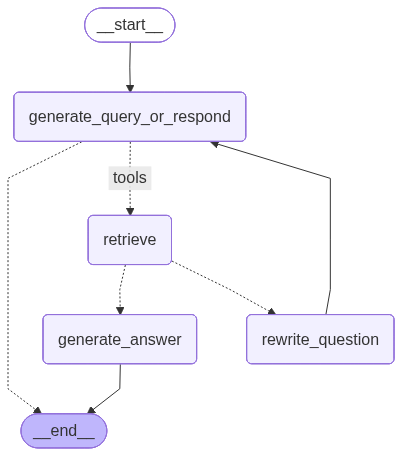

In [116]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [117]:
for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "what is Planning in ISO?",
            }
        ]
    }
):
    for node, update in chunk.items():
        print("Update from node", node)
        update["messages"][-1].pretty_print()
        print("\n\n")

Update from node generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_documents (7bcb2eb1-63ba-4349-be19-842f49f25465)
 Call ID: 7bcb2eb1-63ba-4349-be19-842f49f25465
  Args:
    query: Planning in ISO



Update from node retrieve
================================= Tool Message =================================
Name: retrieve_documents


                Document 1

                Similarity Score: 0.7165

                Source: Data\test.txt
                Page: N/A

                Content:
                information security management system within the organization.
6  Planning
6.1  Actions to address risks and opportunities
6.1.1  General
When planning for the information security management system, the organization shall consider 
the issues referred to in 4.1 and the requirements referred to in 4.2 and determine the risks and 
opportunities that need to be addressed to:
a) ensure the information securi

In [147]:
for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "Hello",
            }
        ]
    }
):
    for node, update in chunk.items():
        print("Update from node", node)
        update["messages"][-1].pretty_print()
        print("\n\n")

Update from node generate_query_or_respond
================================== Ai Message ==================================

Hello! How can I help you today?



